# PROJECT TITLE :
### Customer Churn Prediction using Advanced Data Preprocessing and Exploratory Data Analysis.

# AIM : 
### To analyze customer data using preprocessing and exploratory data analysis techniques and predict whether a customer will churn or not.

# OBJECTIVE :
- Handle missing values
- Remove outliers
- Encode categorical variables
- Perform feature scaling
- Conduct EDA with visualizations
- Build a classififcation model
- Evaluate performance

# DATASET : 
### Kaggle Dataset : TELCO CUSTOMER CHURN DATASET (contain 7000+ records)

#### Columns include:
- Customer ID
- Gender
- Senior Citizen
- Tenure
- Monthly Charges
- Total Charges
- Contract
- Payment Method
- Churn (Target Variable)

# WORKING PRINCIPLE :
#### The project works in the following stages:
- Load Dataset 
- Data Cleaning
- Handling missing values
- Encoding categorical features
- Scaling numerical features
- Exploratory Data analysis
- Feature Selection
- Model Training
- Model evaluation


# IMPLEMENTATION 

## STEP 1: IMPORTING LIBRARIES


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## STEP 2: LOAD DATASET

In [4]:
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

## STEP 3: BASIC DATA INSPECTION

In [5]:
print(df.head())
print(df.info())
print(df.isnull().sum())

   customerID  gender  SeniorCitizen  ... MonthlyCharges TotalCharges  Churn
0  7590-VHVEG  Female              0  ...          29.85        29.85     No
1  5575-GNVDE    Male              0  ...          56.95       1889.5     No
2  3668-QPYBK    Male              0  ...          53.85       108.15    Yes
3  7795-CFOCW    Male              0  ...          42.30      1840.75     No
4  9237-HQITU  Female              0  ...          70.70       151.65    Yes

[5 rows x 21 columns]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-

## STEP 4: DATA CLEANING

In [6]:
# Convert Total Charges to numeric
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

# Fill missing values
df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)

# Drop customerID (not useful)
df.drop('customerID',axis=1,inplace=True)

C:\Users\Mishul Singh\AppData\Local\Temp\ipykernel_18748\259439547.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(),inplace=True)


## STEP 5: ENCODING CATEGORICAL DATA

In [7]:
le=LabelEncoder()
for column in df.columns:
    if df[column].dtype=='object':
        df[column]=le.fit_transform(df[column])

## STEP 6: FEATURE SCALING

In [8]:
scaler=StandardScaler()
numeric_cols=['tenure','MonthlyCharges','TotalCharges']
df[numeric_cols]=scaler.fit_transform(df[numeric_cols])

## STEP 7: EXPLORATORY DATA ANALYSIS

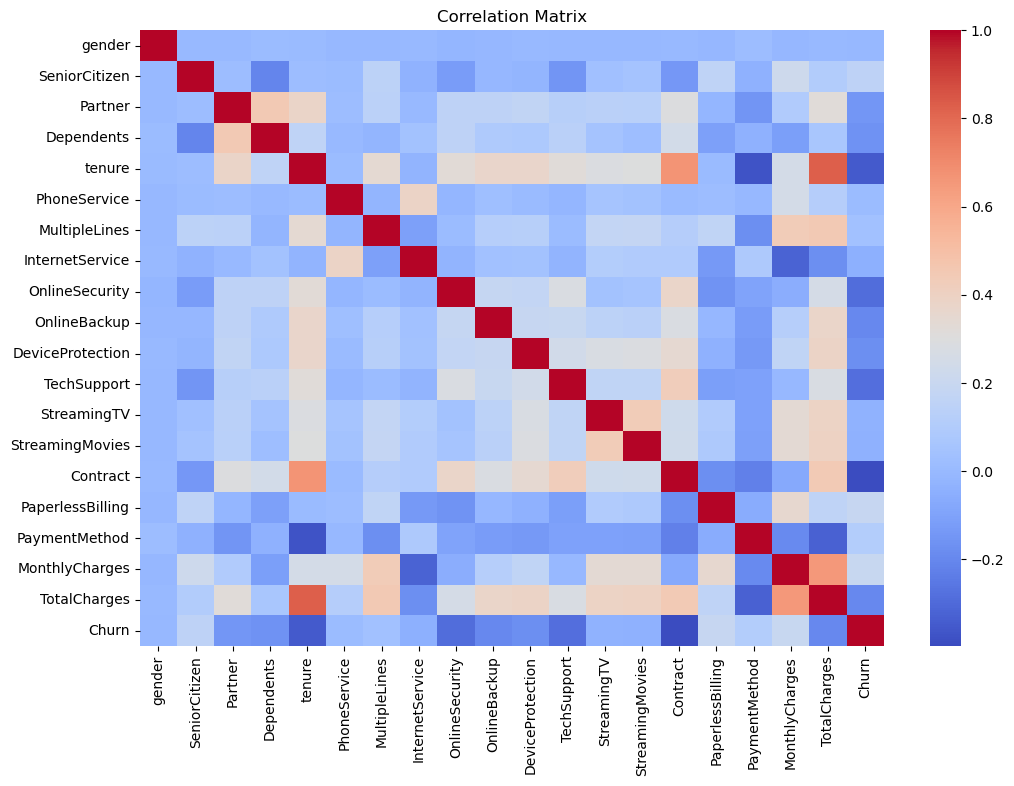

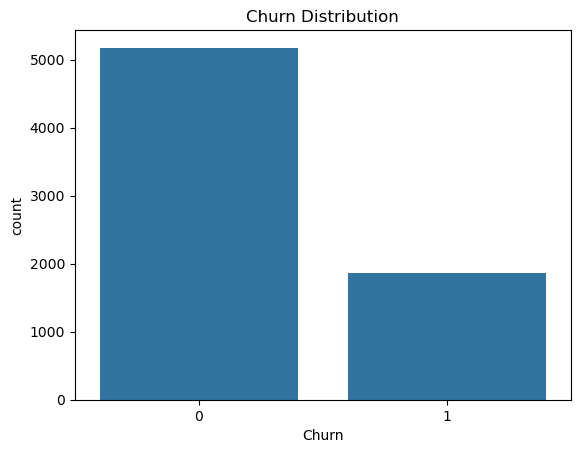

In [10]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(),cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# Churn Distribution
sns.countplot(x='Churn',data=df)
plt.title("Churn Distribution")
plt.show()

## STEP 8: TRAIN-TEST SPLIT

In [11]:
X=df.drop('Churn',axis=1)
y=df['Churn']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

## STEP 9: MODEL TRAINING

In [12]:
model=LogisticRegression()
model.fit(X_train,y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


## STEP 10: PREDICTION

In [13]:
y_pred=model.predict(X_test)

## STEP 11: EVALUATION

Accuracy: 0.8176011355571328

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



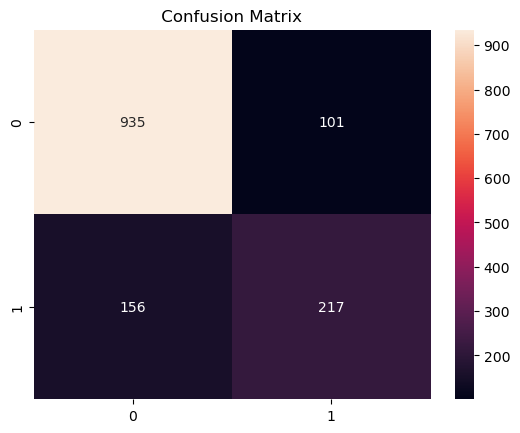

In [14]:
print("Accuracy:",accuracy_score(y_test,y_pred))
print("\nClassification Report:\n",classification_report(y_test,y_pred))
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d')
plt.title(" Confusion Matrix ")
plt.show()